Code to load in the merged_metadata Excel file and filter for relevent metadata columns that could be used to predict water quality (0-poor, 1-moderate, 2-good).

Initially, an MLP (Mylti-Layer Perceptron) is trained and evaluated using a feature vector. 

An XGBoost (Extreme Gradient Boosting) model is also trained and evaluated for a comparison. However, the MLP is expected to perform better as MLPs typically perform better with complex feature learning whilst EGBoost is better with structured data, and its performance depends heavily on the dataset.

These models both use all 3 original classes of water quality as targets.
 

In [1]:
#Import modules

#Basic
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

#Scikit-learn
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#For the models
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

#Explainability
import shap


I0000 00:00:1782467714.835474  179515 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782467714.891964  179515 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782467720.489812  179515 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/t/tichfordr/Documents/Team Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Loading the data
merged_df = pd.read_excel("/home/t/tichfordr/Documents/Team Project/Data/merged_metadata.xlsx")
#Displaying the merged dataframe
merged_df


In [4]:
#Selecting only the columns we want
#Not selecting any empty columns

filtered_df=merged_df[["feature_global_id", "feedback_score","Freshwater body type","What is the main land use within 50m?","You selected other, what is the main land use?", 
                       "What is the main bank vegetation? (select all that apply)","You selected other, what is the main bank vegetation?","Vegetation cover in/on the water (%)",
                       "Is there any of the following on the water surface?", "Estimate the water colour","You selected other, enter the colour"]]

#Displaying the filtered dataframe
filtered_df
#feedback score - 1-poor, 3-good -changes to 0...2

,feature_global_id,feedback_score,Freshwater body type,What is the main land use within 50m?,"You selected other, what is the main land use?",What is the main bank vegetation? (select all that apply),"You selected other, what is the main bank vegetation?",Vegetation cover in/on the water (%),Is there any of the following on the water surface?,Estimate the water colour,"You selected other, enter the colour"
0,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,1,River,Forest,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
1,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,2,Stream,Rural_residential,NaN,"Grass_small_plants,Trees_shrubs",NaN,NaN,NaN,Colourless,NaN
2,9ab3ef19-b92e-495d-8330-e5cab4f52139,3,River,Urban_green_space,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
3,7065d44e-868d-41a8-bc29-3e380d44a284,1,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
4,ece94aea-b3a2-4c72-a1b0-66b329185eb8,3,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Concrete_imper...",NaN,NaN,NaN,Colourless,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8999,7479327a-dda2-4647-8e19-176fc7b7c208,3,River,Grassland_shrub,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9000,9ca17c49-6a38-405f-8369-caebcbb4c445,1,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,Foam,Brown,NaN
9001,f077fd29-55c0-484c-8b03-aa1d54844b54,1,River,Arable_agricultural,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9002,8279d341-cfc1-4852-8b19-a58dc6eee304,2,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,NaN,Colourless,NaN


In [ ]:
#Dataframe pre-processing for ML training 
#Need to change the data from categories to numerical values and normalise. 

#Splitting the columns into different data types. 
multilabel_col = "What is the main bank vegetation? (select all that apply)"
nominal_cols = [
    "Freshwater body type",
    "What is the main land use within 50m?",
    "Is there any of the following on the water surface?",
    "Estimate the water colour"
]
numeric_cols = ["Vegetation cover in/on the water (%)"]
TARGET = "feedback_score"

filtered_df = filtered_df.copy()

def normalize_multilabel(x):
    #Explicit handling for list/array-like types
    if isinstance(x, (list, tuple, set, np.ndarray)):
        #Convert to plain python list of stripped strings
        out = []
        for v in x:
            if v is None:
                continue
            s = str(v).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out

    #Now use pd.isna
    if pd.isna(x):
        return []

    #Split strings/other scalars on the comma
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none"):
        return []
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts

#Apply normalisation WITHOUT assigning lists into the original string column
bank_veg_lists = filtered_df[multilabel_col].astype("object").map(normalize_multilabel)

#Build bank_veg_df using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
bank_veg_encoded = mlb.fit_transform(bank_veg_lists)
bank_veg_df = pd.DataFrame(
    bank_veg_encoded,
    index=filtered_df.index,
    columns=[f"bankveg_{c}" for c in mlb.classes_]
)
print("bank_veg_df.shape:", bank_veg_df.shape)
print("bankveg classes (sample):", mlb.classes_[:20])

#Ensure nominal columns are strings (no lists)
def to_str_val(v):
    if isinstance(v, (list, tuple, set, np.ndarray)):
        return "|".join([str(x).strip() for x in v if x is not None and str(x).strip().lower() not in ("nan","none")])
    if pd.isna(v):
        return ""
    return str(v).strip()

for c in nominal_cols:
    filtered_df.loc[:, c] = filtered_df[c].apply(to_str_val)

#Numeric fill
filtered_df.loc[:, numeric_cols] = filtered_df[numeric_cols].astype(float).fillna(0.0)

#ColumnTransformer (exclude multi-label col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)

X_base_arr = preprocessor.fit_transform(filtered_df)

#Check if X_base_arr is sparse and make dense
try:
    from scipy import sparse
    if sparse.issparse(X_base_arr):
        X_base_arr = X_base_arr.toarray()
except Exception:
    pass

#Set column names
try:
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
    base_cols = list(numeric_cols) + list(cat_names)
except Exception:
    base_cols = [f"base_{i}" for i in range(X_base_arr.shape[1])]

X_base_df = pd.DataFrame(X_base_arr, index=filtered_df.index, columns=base_cols[:X_base_arr.shape[1]])
bank_veg_df = bank_veg_df.reindex(filtered_df.index).fillna(0).astype(int)
X_df = pd.concat([X_base_df, bank_veg_df], axis=1)
X = X_df.values
y = filtered_df[TARGET].astype(int).values - 1

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


bank_veg_df.shape: (9004, 5)
bankveg classes (sample): ['Bare_soil' 'Concrete_impermeable_surface' 'Grass_small_plants' 'Other'
 'Trees_shrubs']
Final X shape: (9004, 64)
Final y shape: (9004,)


In [6]:
#Checking the shapes of X and y and the new target classes, now 0..2 instead of 1..3
print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y.shape)   # (n_samples,)
print("y classes:", np.unique(y))

X shape: (9004, 64)
y shape: (9004,)
y classes: [0 1 2]


In [7]:
#Divide the data into training, validation and testing. 

#Split test off from training+validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

#Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
#Final 80/10/10 split

print(X_train.shape, X_val.shape, X_test.shape)


(7202, 64) (901, 64) (901, 64)


In [8]:
#MPL model
#Training

#Setting parameters and loading training data
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

# Cap extreme weights
for k in class_weight:
    class_weight[k] = min(class_weight[k], 3.0)

#Building the model using keras with dropout
model = tf.keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

#Setting Adam as the optimiser
opt = tf.keras.optimizers.Adam(learning_rate=5e-5)   # try 1e-4 or 5e-5
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

#Storing the model history
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[es,rlr]
)

#Evaluating the model on the test set
y_test_cat = to_categorical(y_test, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

#Detailed classification metrics on validation set
y_val_proba = model.predict(X_val)
y_val_pred = np.argmax(y_val_proba, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

#Compute metrics
print("\nValidation accuracy:", accuracy_score(y_val_true, y_val_pred))
print("\nClassification report (val):")
print(classification_report(y_val_true, y_val_pred, digits=4))

print("\nConfusion matrix (val):")
print(confusion_matrix(y_val_true, y_val_pred))


Epoch 1/30


E0000 00:00:1782467730.690479  179515 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3673 - loss: 1.1673 - val_accuracy: 0.3263 - val_loss: 1.1601 - learning_rate: 5.0000e-05
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3557 - loss: 1.1609 - val_accuracy: 0.3141 - val_loss: 1.1596 - learning_rate: 5.0000e-05
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3785 - loss: 1.1550 - val_accuracy: 0.3596 - val_loss: 1.1577 - learning_rate: 5.0000e-05
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3791 - loss: 1.1509 - val_accuracy: 0.3785 - val_loss: 1.1531 - learning_rate: 5.0000e-05
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4016 - loss: 1.1463 - val_accuracy: 0.3829 - val_loss: 1.1511 - learning_rate: 5.0000e-05
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4122 - loss: 1.1418 - val_accuracy: 0.4218 - val_loss: 1.1435 - learning_rate: 5.0000e-05
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4196 - lo

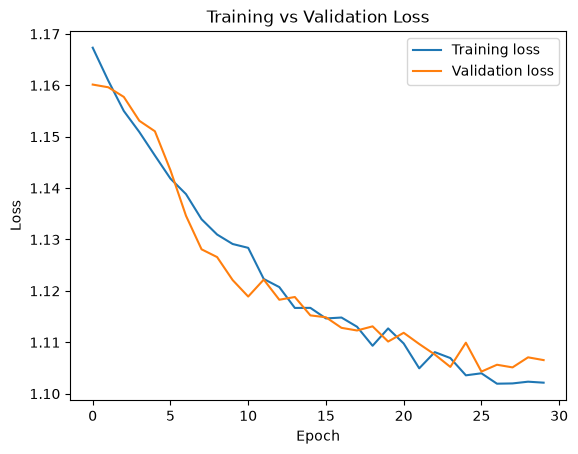

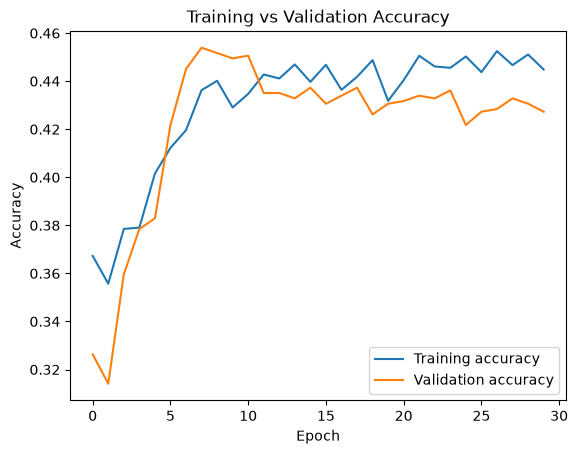

In [9]:
#Inspection of training process
#Loss curve
plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.savefig('/home/t/tichfordr/Documents/Team Project/Results/3 classes/training_v_validation_loss.png')
plt.show()

#Accuracy curve
plt.figure()
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.savefig('/home/t/tichfordr/Documents/Team Project/Results/3 classes/training_v_validation_accuracy.png')
plt.show()


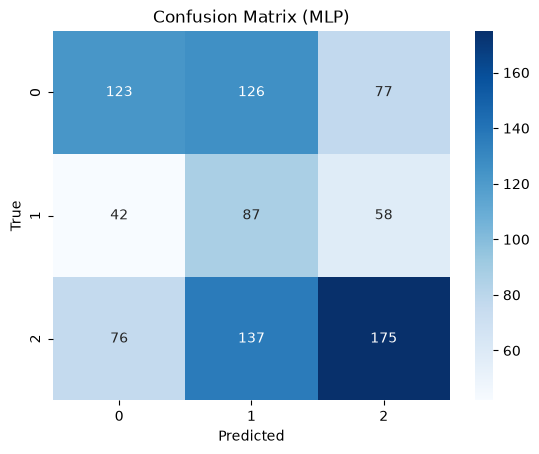

In [ ]:
#Confusion matrix heatmap
if y_val_pred.ndim == 2 and y_val_pred.shape[1] > 1:
    y_val_pred_labels = np.argmax(y_val_pred, axis=1)
else:
    y_val_pred_labels = y_val_pred
    
cm = confusion_matrix(y_val, y_val_pred_labels)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (MLP)")
plt.savefig('/home/t/tichfordr/Documents/Team Project/Results/3 classes/confusion_matrix.png')
plt.show()